# Calculating T90 for Unmask Weighted counts

In [1]:
import batanalysis as ba
import swiftbat
from swifttools.swift_too import ObsQuery 

import matplotlib.pyplot as plt
import numpy as np
import scipy as sp
from pathlib import Path
from astropy.io import fits
from astropy.time import Time, TimeDelta
import astropy.units as u
from astropy.coordinates import SkyCoord
import datetime
import os
from swifttools.swift_too import GUANO
from swifttools.swift_too import Data
from astropy.stats import bayesian_blocks
from astropy.table import Table
from astropy.table import vstack
from astropy.io import fits
from scipy.stats import linregress
from astropy.stats import bayesian_blocks  

In [2]:
from nitrates.lib.dmask_funcs import combine_detmasks, get_hotpix_map, find_rate_spike_dets2mask
from nitrates.lib.event2dpi_funcs import filter_evdata, mask_detxy
from nitrates.lib.gti_funcs import (
        add_bti2gti,
        bti2gti,
        gti2bti,
        union_gtis,
        flags2gti,
        get_btis_for_glitches,
        check_if_in_GTI,
        find_and_remove_cr_glitches,
    )


sh: https://heasarc.gsfc.nasa.gov/FTP/caldb/caldbinit.sh: No such file or directory


No module named 'ROOT'
Please install the Python ROOT package to be able to run the full forward modeling calculations.
16
16
[array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14]), array([19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]), array([37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50]), array([55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68]), array([73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86]), array([ 91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104]), array([109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121,
       122]), array([127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139,
       140]), array([145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157,
       158]), array([163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175,
       176]), array([181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193,
       194]), array([199, 200, 201, 202, 203, 

In [3]:
def calculate_t90_grb(
    trigger_time: float,
    event_file_path,
    acs_file_path,
    enb_mask_path,
    output_dir,
    event,
    emin: float = 14.0,
    emax: float = 500.0
):
    
    # Step 1: Create a detector mask
    def mk_dmask(enb_mask_fname, evdata, save_dir='.'):
        enb_tab = Table.read(enb_mask_fname)
        mid_ev_time = 0.5 * (np.min(evdata["TIME"]) + np.max(evdata["TIME"]))
        best_ind = np.argmin(np.abs(mid_ev_time - enb_tab["TIME"]))
        det_enb_mask = enb_tab["FLAG"][best_ind]
        bl_det_enb = (det_enb_mask == 0)
        mask_zeros = len(evdata) / float(np.sum(bl_det_enb)) > 14
        hotpix_map = get_hotpix_map(evdata, bl_det_enb, mask_zeros=mask_zeros)
        dmask = combine_detmasks([det_enb_mask, hotpix_map])
        blev = mask_detxy(dmask, evdata) == 0.0
        for det in find_rate_spike_dets2mask(evdata[blev]):
            dmask[det[0], det[1]] = 1
        fname = os.path.join(save_dir, "detmask.fits")
        fits.PrimaryHDU(dmask).writeto(fname, overwrite=True)
        return fname
    
    # Step 2: Filter event data using mask and GTIs
    def evfnames2write(evfnames, dmask, save_dir, acs_tab):
        tabs, gti_pnts, gti_slews, gti_slewpnts, all_gtis = [], [], [], [], []
        for evf in evfnames:
            tab = Table.read(evf)
            evf_str = str(evf)
            if "bevshpo" in evf_str or "filter_evdata" in evf_str:
                tab["SLEW"] = np.zeros(len(tab), dtype=np.int64)
                gti_pnts.append(Table.read(evf, hdu=2))
            elif "bevshsl" in evf_str:
                tab["SLEW"] = np.ones(len(tab), dtype=np.int64)
                gti_slews.append(Table.read(evf, hdu=2))
            else:
                tab["SLEW"] = 2 * np.ones(len(tab), dtype=np.int64)
                gti_slewpnts.append(Table.read(evf, hdu=2))
            tabs.append(tab)
        ev_data = vstack(tabs)
        ev_data.sort("TIME")
        ev_data0 = filter_evdata(ev_data, dmask, emin, emax, trigger_time - 60, trigger_time + 160)
        if gti_pnts: all_gtis.append(vstack(gti_pnts)); gti_pnt = all_gtis[-1]; gti_pnt.sort("START")
        else: gti_pnt = Table(names=("START", "STOP"))
        if gti_slews: all_gtis.append(vstack(gti_slews)); gti_slew = all_gtis[-1]; gti_slew.sort("START")
        else: gti_slew = Table(names=("START", "STOP"))
        if gti_slewpnts:
            gti_slewpnt = vstack(gti_slewpnts); gti_slewpnt.sort("START"); all_gtis.append(gti_slewpnt)
            gti_data_pnt = add_bti2gti(gti2bti(flags2gti(acs_tab["TIME"], acs_tab["FLAGS"][:, 0])), gti_slewpnt)
            gti_pnts.append(gti_data_pnt); gti_pnt = vstack(gti_pnts); gti_pnt.sort("START")
        else: gti_slewpnt = Table(names=("START", "STOP"))
        gti_tot = union_gtis(all_gtis) if len(all_gtis) > 1 else all_gtis[0]
        for bti in get_btis_for_glitches(ev_data0, gti_tot["START"][0], gti_tot["STOP"][-1]):
            gti_pnt = add_bti2gti(bti, gti_pnt); gti_tot = add_bti2gti(bti, gti_tot); gti_slew = add_bti2gti(bti, gti_slew)
        ev_data0 = find_and_remove_cr_glitches(ev_data0, gti_pnt)
        hdu_list = fits.HDUList([
            fits.PrimaryHDU(),
            fits.BinTableHDU(ev_data0, name="EVENTS"),
            fits.BinTableHDU(gti_tot, name="GTI"),
            fits.BinTableHDU(gti_pnt, name="GTI_POINTING"),
            fits.BinTableHDU(gti_slew, name="GTI_SLEW"),
            fits.BinTableHDU(gti_slewpnt, name="GTI_SLEW_POINTING")
        ])
        fname = os.path.join(save_dir, "filtered_evdata.fits")
        hdu_list.writeto(fname, overwrite=True)
        return fname

    # Step 3: Count rate integration over time (used to get cumulative counts)
    def tc(t1, edges, rates, fraction=0.05):
        rate_t = np.zeros_like(t1) * (u.ct / u.s)
        rate_threshold=fraction * np.max(rates)
        for i in range(len(t1)):
            ind = np.clip(np.digitize(t1[i], edges) - 1, 0, len(rates) - 1)
            if rates[ind] >= rate_threshold:
                rate_t[i] = rates[ind]
            else:
                rate_t[i] = 0.0 * (u.ct / u.s)
        return np.cumsum(rate_t) * (t1[1] - t1[0])

    # Main execution begins here
    table = Table.read(event_file_path)
    acs_tab = Table.read(acs_file_path, hdu='ACS_DATA')
    cutoff_table = table[(table["TIME"] > trigger_time - 60) & (table["TIME"] < trigger_time + 160)]
    #We only need the data in a small range of time near trigger time,
    #the time outside this range may affect the results.
    dmask_fname = mk_dmask(enb_mask_path, cutoff_table, save_dir=output_dir)
    dmask = fits.open(dmask_fname)[0].data
    filtered_evfname = evfnames2write([event_file_path], dmask, output_dir, acs_tab)
    
    # Step 4: Background modeling
    filtered_evtab = Table.read(filtered_evfname)
    GTI = Table.read(filtered_evfname, hdu='GTI')#Useful time interval
    event_times = filtered_evtab['TIME']
    time_min, time_max = GTI['START'][0], GTI['STOP'][0]
    bins_raw = np.arange(time_min, time_max)
    counts_raw, edges_raw = np.histogram(event_times, bins=bins_raw)
    time_midpoints_raw = 0.5 * (edges_raw[:-1] + edges_raw[1:])
    time_bin_size = bins_raw[1] - bins_raw[0]
    rates_raw = (counts_raw / time_bin_size) * (u.ct / u.s)
    dt_raw = time_midpoints_raw - trigger_time
    bg_mask = ((dt_raw > -50) & (dt_raw < -10)) | ((dt_raw > 100) & (dt_raw < 150))
    #For estimating the background fit, we need to exclude the rate around trigger time.
    
    # Linear regression to estimate background
    slope, intercept, _, _, stderr = linregress(dt_raw[bg_mask], rates_raw[bg_mask])
    counts_bkg = np.sum(counts_raw[bg_mask]) 
    duration_bkg = np.sum(np.diff(edges_raw)[bg_mask])
    intercept_stderr =(np.sqrt(counts_bkg) / duration_bkg) * (u.ct / u.s)
    stderr=stderr*(u.ct/u.s)
    print(stderr)
    print(intercept_stderr)
    
    # Step 5: Signal estimation and S/N calculation
    bg_rate = slope * dt_raw + intercept #A linear approximation of the back ground rate.
    plt.figure(figsize=(10, 5))
    plt.step(dt_raw, rates_raw, where='mid', color='blue')
    plt.plot(dt_raw, bg_rate, color='red')
    plt.xlabel('Time')
    plt.ylabel('Count Rate')
    plt.grid(True)
    plt.xlim(-25,40)
    plt.ylim(0,8000)
    plt.show()
    net_rate = np.clip(rates_raw - bg_rate * (u.ct / u.s), 0, None)
    GTI_POINTING = Table.read(filtered_evfname, hdu='GTI_POINTING')
    print(GTI_POINTING)#The time interval without slew, we don't need to consider the rate after it starts slew.
    i = 0
    while i < len(GTI_POINTING) and GTI_POINTING['STOP'][i] < trigger_time:
        i += 1
    GTI_POINTING_STOP=GTI_POINTING['STOP'][i]
    #There are multiple time intervals, make sure it contains the trigger.
    
    #Using Bayesian Block here.
    maskstop = min(GTI_POINTING_STOP-trigger_time, 40)
    dt_mask = (dt_raw < maskstop) & (dt_raw > -30)#We only want the information close to trigger.
    t_1 = dt_raw[dt_mask]
    x_1 = net_rate[dt_mask]
    sigma_1 = (np.sqrt(counts_raw) / time_bin_size)[dt_mask]
    edges_1 = bayesian_blocks(t_1, x_1, sigma_1, fitness='measures')
    
    #We use edges_1 to recreate a light curve
    event.create_lightcurve(timebins=edges_1 * u.s, timebinalg="bayesian")
    event_times_2 = filtered_evtab['TIME'] - trigger_time
    counts_rawedges, _ = np.histogram(event_times_2, bins=edges_1)
    rates_rawedges = counts_rawedges / np.diff(edges_1)
    dt_rawedges = 0.5 * (edges_1[:-1] + edges_1[1:])
    signal_rates = np.clip(rates_rawedges - (slope * dt_rawedges + intercept),0, None) * (u.ct / u.s)
    signal_counts = signal_rates*np.diff(edges_1)
    rate_err = np.sqrt((stderr * dt_rawedges)**2 + intercept_stderr**2)
    
    # S/N threshold to define signal region
    gradient = (slope * dt_rawedges + intercept)*(u.ct**2/u.s**2)
    noise = np.sqrt((gradient * np.diff(edges_1)) + (rate_err * np.diff(edges_1))**2)
    SN=signal_counts/noise
    print("SN",SN)
    sn_mask = SN.value >= 3
    if np.any(sn_mask):
        i_start = np.argmax(sn_mask)
        i_end = len(sn_mask) - 1 - np.argmax(sn_mask[::-1])
        edges_signal = edges_1[i_start:i_end+2]  # note the +2 to include final bin edge
    else:
        edges_signal = edges_1
    print("edges1:", edges_1)
    print("edgessingal:", edges_signal)
    
    # Step 6: T90 calculation from cumulative counts
    t1 = np.arange(edges_signal[0], edges_signal[-1], 0.01)
    cumulative_counts = tc(t1, edges_1, signal_rates)
    total_counts = cumulative_counts[-1]
    lower_5 = 0.05 * total_counts
    upper_95 = 0.95 * total_counts
    idx_5 = np.searchsorted(cumulative_counts, lower_5)
    idx_95 = np.searchsorted(cumulative_counts, upper_95)
    t_start, t_end = t1[idx_5], t1[idx_95]
    T90 = t_end - t_start
    return t_start, t_end, T90

# Example

In [4]:
oq = ObsQuery(begin="2024-04-21 09:43:24", length=0.1) #Collecting the data
oq

2024-04-21 09:28:35,2024-04-21 09:43:37,CXOU J164710.2-455216,00015870016,775,127
2024-04-21 09:43:42,2024-04-21 10:14:28,,01223470000,1740,106
2024-04-21 10:14:29,2024-04-21 10:15:41,4U 1909+07,00016436027,0,72
2024-04-21 10:15:44,2024-04-21 10:20:58,GRB 240419B,01223072006,225,89
2024-04-21 10:21:02,2024-04-21 10:26:57,J231617.6-135545,00090964002,270,85
2024-04-21 10:27:02,2024-04-21 10:44:00,AT2019QIZ,00097575004,820,198
2024-04-21 10:44:02,2024-04-21 10:53:57,AT2024as,00016500014,445,150
2024-04-21 10:54:02,2024-04-21 11:06:59,NGC 4395,00097137183,675,102
2024-04-21 11:07:04,2024-04-21 11:15:58,UCAC4 744-049386,00097340001,450,84
2024-04-21 11:16:02,2024-04-21 11:35:57,,01223470001,1025,170
2024-04-21 11:36:02,2024-04-21 11:38:26,T CRB,00097564012,0,144


In [5]:
data = Data(obsid=oq[1].obsid, bat=True, outdir="~/work/Downloads/", clobber=True)#Downloading the data

In [6]:
event=ba.BatEvent(oq[1].obsid,obs_dir = "/storage/home/zbl5364/work/Downloads/", is_guano=True, recalc = True, ra = 299.68*u.deg, dec = -14.87*u.deg)

A save file has been written to /storage/work/zbl5364/Downloads/01223470000_eventresult/batevent.pickle.


In [7]:
event.event_files

PosixPath('/storage/work/zbl5364/Downloads/01223470000_eventresult/events/sw01223470000bevshsp_uf.evt')

(800, 285, 172)
4.0 0.0021316809465524275
(400, 151, 55)
735385355.3600974 150.5 54.5
0.0023051815585475315 113.0

(800, 285, 172)
4.0 0.0021166615667074663
(488, 152, 144)
735385373.1200957 151.5 143.5
0.002345981232150143 115.0

(800, 285, 172)
5.0 0.002127218482252142
(51, 114, 143)
735385380.3801041 113.5 142.5
0.001937984496124031 95.0

(800, 285, 172)
3.0 0.002310842513259894
(195, 30, 33)
735385399.2601013 29.5 32.5
0.0023663810689514486 116.0

(800, 285, 172)
4.0 0.0021341799265605873
(259, 123, 135)
735385416.5401001 122.5 134.5
0.0025499796001631986 125.0

(800, 285, 172)
3.0 0.002107889636882905
(88, 83, 84)
735385429.1201034 82.5 83.5
0.001795185638514892 88.0

(800, 285, 172)
3.0 0.002114264585883313
(5, 174, 125)
735385443.460105 173.5 124.5
0.002325581395348837 114.0

(800, 285, 172)
4.0 0.002059644022847817
(471, 151, 12)
735385468.780096 150.5 11.5
0.0021215830273357814 104.0

(800, 285, 172)
4.0 0.0019252600979192166
(20, 187, 6)
735385475.7601047 186.5 5.5
0.00238678

0.11897638626324106 ct / s
7.60838556227256 ct / s


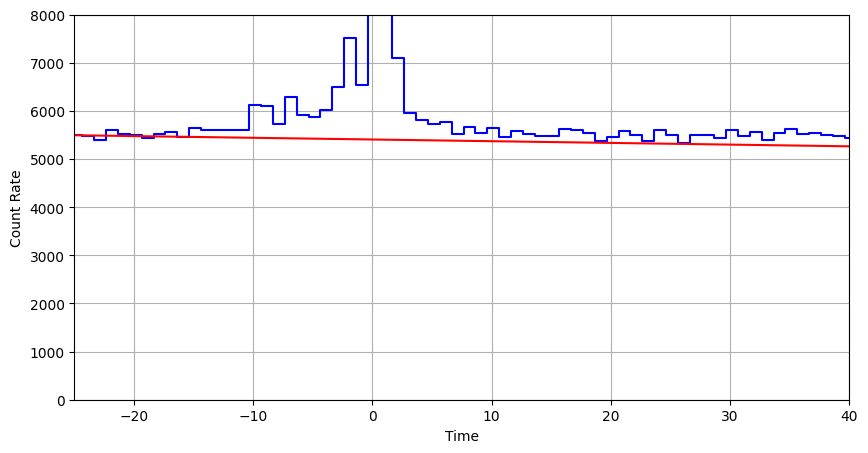

    START           STOP     
-------------- --------------
   735385168.0 735385422.6006
735385516.2006 735386370.0257
SN [ 0.54189369  4.64511536 12.85238602  4.00538895 11.62586332 11.89393654
 14.60330126 28.41800704 15.37129511 66.32818842 51.81013994 23.16437707
 11.48522709  6.6086884 ]
edges1: [-29.86000001 -15.36000001 -10.36000001  -8.36000001  -7.36000001
  -6.36000001  -3.36000001  -2.36000001  -1.36000001  -0.36000001
   0.63999999   1.63999999   2.63999999   6.63999999  15.13999999]
edgessingal: [-15.36000001 -10.36000001  -8.36000001  -7.36000001  -6.36000001
  -3.36000001  -2.36000001  -1.36000001  -0.36000001   0.63999999
   1.63999999   2.63999999   6.63999999  15.13999999]
T90 start = -8.840
T90 end   = 4.260
T90       = 13.100


In [9]:
t_start, t_end, T90 = calculate_t90_grb(
    trigger_time=735385407.36,
    event_file_path="Downloads/01223470000_eventresult/events/sw01223470000bevshsp_uf.evt",
    acs_file_path=Path("Downloads/01223470000/auxil/sw01223470000pat.fits.gz"),
    enb_mask_path=Path("Downloads/01223470000/bat/hk/sw01223470000bdecb.hk.gz"),
    output_dir=Path("Downloads/01223470000"),
    event=event
)

print(f"T90 start = {t_start:.3f}")
print(f"T90 end   = {t_end:.3f}")
print(f"T90       = {T90:.3f}")